<a href="https://colab.research.google.com/github/mahitha2005/My_Project/blob/main/Stock_Price_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance pandas numpy matplotlib scikit-learn tensorflow

In [ ]:
import yfinance as yf
import pandas as pd

# Download stock data (example: Apple)
df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

print(df.head())

/tmp/ipykernel_2889/1360235547.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.214893  24.682226  23.776353  24.671151  212818400
2015-01-05  23.532722  24.064285  23.346676  23.984551  257142000
2015-01-06  23.534941  23.794077  23.173920  23.596956  263188400
2015-01-07  23.864952  23.964619  23.632393  23.743135  160423600
2015-01-08  24.781891  24.839477  24.075355  24.192743  237458000


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Use closing price
data = df[['Close']]

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from sklearn.linear_model import LinearRegression

# Flatten data for regression
X_lr = X.reshape(X.shape[0], -1)

X_train_lr = X_lr[:split]
X_test_lr = X_lr[split:]

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

lr_predictions = lr_model.predict(X_test_lr)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0086
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 4.0974e-04
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 3.6001e-04
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 3.4903e-04
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 3.4023e-04
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 3.8002e-04
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 3.0627e-04
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 2.9167e-04
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 3.0597e-04
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 3.1827e-04


In [ ]:
lstm_predictions = model.predict(X_test)

# Convert back to original scale
lstm_predictions = scaler.inverse_transform(lstm_predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step


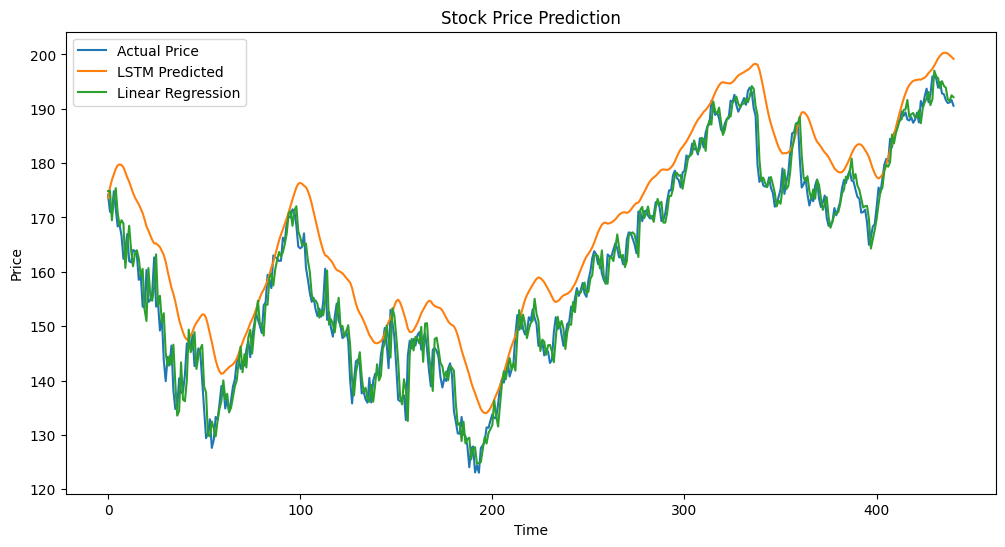

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(lstm_predictions, label="LSTM Predicted")
plt.plot(scaler.inverse_transform(lr_predictions.reshape(-1,1)), label="Linear Regression")

plt.legend()
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [ ]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

future_price = model.predict(last_60_days)
future_price = scaler.inverse_transform(future_price)

print("Next Day Predicted Price:", future_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Next Day Predicted Price: 198.80737
